# Price Driver Analysis



In [ ]:
# Done By: Kedar Raju Pawar
# date:2026-02-25 time: 13:45:00

### Load dataset and inspect

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("../../02_Data_Management/04_Processed_Data/analytics_dataset.csv")
df.columns

Index(['Company', 'laptop_type', 'screen_size_inch',
       'display_resolution_width', 'display_resolution_height', 'panel_type',
       'is_touchscreen', 'resolution_class', 'cpu_brand', 'cpu_family',
       'cpu_generation', 'clock_speed_ghz', 'cpu_tier', 'gpu_brand', 'ram_gb',
       'ssd_gb', 'hdd_gb', 'flash_gb', 'hybrid_gb', 'total_storage_gb',
       'weight_kg', 'weight_class', 'price_band', 'Price', 'is_price_outlier'],
      dtype='object')

### STEP 1 — Define Hypotheses

- H0 (Null Hypothesis):
- The mean price is equal across all CPU tiers.
    
- **𝜇𝐸𝑛𝑡𝑟𝑦=𝜇𝐿𝑜𝑤𝑒𝑟𝑀𝑖𝑑=𝜇𝑀𝑖𝑑=𝜇𝑈pperMid=𝜇High**

- H1 (Alternative Hypothesis):
- At least one CPU tier has a mean price significantly different from the others.

### STEP 2 — Check Group Sizes

In [4]:
df["cpu_tier"].value_counts()

cpu_tier
High         405
Upper-Mid    351
Mid          117
Entry        112
Lower-Mid     15
Name: count, dtype: int64

### STEP 3 — Check Assumptions

#### Check Group Means First

In [6]:
df.groupby("cpu_tier")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
cpu_tier,,,,,,,,
Entry,112.0,18708.368143,5384.725893,10224.4320,14851.6668,18221.7600,20725.92,41292.00
High,405.0,86815.605476,39299.808809,30849.1200,58554.7200,79215.1056,105228.00,324954.72
Lower-Mid,15.0,25566.905280,4268.373956,21045.6000,22084.5600,24988.3200,26320.32,34632.00
Mid,117.0,32999.673846,19455.358881,18381.0672,23922.7200,28185.1200,34898.40,165168.00
Upper-Mid,351.0,52642.440287,19670.921122,20986.9920,37242.7200,48964.3200,62444.16,124142.40


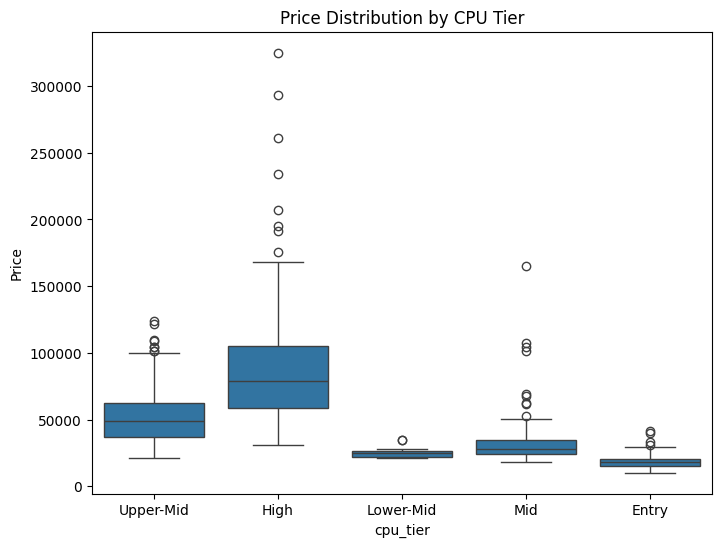

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(x="cpu_tier", y="Price", data=df)
plt.title("Price Distribution by CPU Tier")
plt.show()

### STEP 4 — Run ANOVA

In [11]:
groups=[group["Price"].values for name,group in df.groupby("cpu_tier")]

f_stat,p_value=stats.f_oneway(*groups)
print(f"F_statistic:{f_stat}")
print(f"P_Value:{p_value}")

F_statistic:186.31009329998636
P_Value:3.5026738747702703e-119


#### Interpretation Rule

- If p < 0.05 → Significant difference exists

- If p ≥ 0.05 → No statistical evidence of mean differen

### conclusion:

- We reject the null hypothesis (H₀).
- One-way ANOVA indicates a statistically significant difference in average laptop prices across CPU tiers
- (F = 186.31, p < 0.001).
- The extremely low p-value confirms that pricing varies systematically with processor tier.
- The magnitude of the F-statistic suggests substantial between-tier variation relative to within-tier variation, indicating strong structural segmentation.

### Statistical significance ≠ logical progression.

In [12]:
df.groupby("cpu_tier")["Price"].mean().sort_values()

cpu_tier
Entry        18708.368143
Lower-Mid    25566.905280
Mid          32999.673846
Upper-Mid    52642.440287
High         86815.605476
Name: Price, dtype: float64

- Mean prices increase monotonically across CPU tiers:
    
    - Entry < Lower-Mid < Mid < Upper-Mid < High
    
    - This confirms that higher processor tiers are consistently associated with higher price positioning.
    
    - The combination of:
        
        - Large F-statistic (186.31)
        
        - Extremely small p-value
        
        - Monotonic price progression

- provides strong evidence that CPU tier functions as a primary structural pricing determinant in the dataset.